# Bayesian Optimization

This notebook runs Gaussian-process Bayesian optimization to search the LightGBM hyperparameter space and saves the evaluated trials to the results directory.

Data loaded successfully: (200000, 200)


,trial,method,value,cv_std,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda
3,4,bayesian_optimization,0.883894,0.002537,433,0.122559,14,8,34,0.626021,0.974443,4.828160,8.083973
21,22,bayesian_optimization,0.881471,0.002475,433,0.200000,22,3,21,0.684471,0.688091,3.600663,8.250910
10,11,bayesian_optimization,0.880942,0.002111,439,0.187521,12,5,29,0.648077,0.855854,4.097918,5.831002
22,23,bayesian_optimization,0.880881,0.001872,432,0.200000,23,3,25,0.984736,0.920056,5.000000,2.081034
23,24,bayesian_optimization,0.880520,0.002618,427,0.200000,22,3,21,0.893573,0.661512,1.672609,3.900604


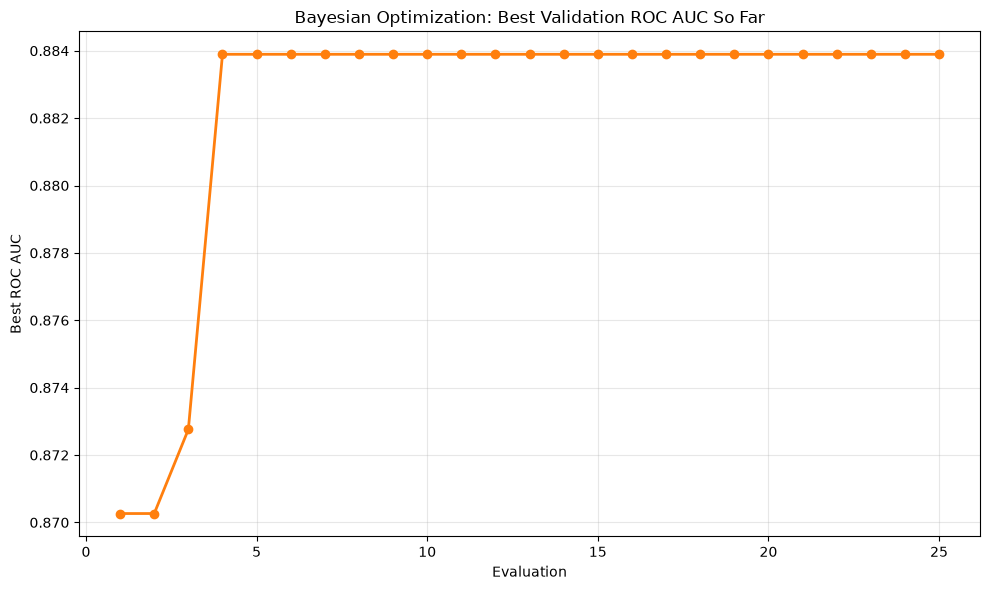

Best observed configuration:
{'target': np.float64(0.88389432348661), 'params': {'n_estimators': np.float64(432.82894112748636), 'learning_rate': np.float64(0.12255876808378806), 'num_leaves': np.float64(13.574049526399726), 'max_depth': np.float64(8.467903667112946), 'min_child_samples': np.float64(33.87337731622081), 'subsample': np.float64(0.6260206371941118), 'colsample_bytree': np.float64(0.9744427686266666), 'reg_alpha': np.float64(4.828160165372797), 'reg_lambda': np.float64(8.08397348116461)}}


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_data, split_features_target
from src.optimization import bayesian_search
from src.objective import CVConfig

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "train.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = load_data(path=DATA_PATH)
X, y = split_features_target(df)

print("Data loaded successfully:", X.shape)

optimizer, results = bayesian_search(
    X,
    y,
    init_points=5,
    n_iter=20,
    seed=42,
    cfg=CVConfig(),
)

results.to_csv(
    RESULTS_DIR / "bayesian_optimization_results.csv",
    index=False,
)

display(
    results.sort_values(
        by="value",
        ascending=False,
    ).head()
)

results = results.sort_values(by="trial").reset_index(drop=True)
results["best_so_far"] = results["value"].cummax()

plt.figure(figsize=(10, 6))
plt.plot(
    results["trial"],
    results["best_so_far"],
    marker="o",
    linewidth=2,
    color="tab:orange",
)
plt.title("Bayesian Optimization: Best Validation ROC AUC So Far")
plt.xlabel("Evaluation")
plt.ylabel("Best ROC AUC")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Best observed configuration:")
print(optimizer.max)
